In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets] matplotlib seaborn
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuració visual
plt.style.use('ggplot')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Carregar dataset
file_path = "student_depression_dataset.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "adilshamim8/student-depression-dataset",
    file_path,
)

print(f"Dataset carregat: {df.shape[0]} files x {df.shape[1]} columnes")
df.head()

/tmp/ipykernel_18809/2370541193.py:17: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Dataset carregat: 27901 files x 18 columnes


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


# 🧠 Exploració del Dataset: Student Depression

Anàlisi exploratori de dades (EDA) del dataset **Student Depression Dataset** de Kaggle.

**Objectius:**
1. Entendre l'estructura i qualitat de les dades
2. Explorar distribucions de variables numèriques i categòriques
3. Analitzar correlacions amb la variable objectiu (`Depression`)
4. Extreure conclusions i identificar patrons rellevants

**Variable objectiu:** `Depression` (0 = No depressió, 1 = Depressió)

## 1. Informació bàsica del dataset

Explorar l'estructura: tipus de dades, valors nuls, estadístiques descriptives.

In [4]:
# Informació general del dataset
print("=" * 50)
print("ESTRUCTURA DEL DATASET")
print("=" * 50)
print(f"\nForma: {df.shape[0]} files × {df.shape[1]} columnes")
print(f"\nColumnes ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col} ({df[col].dtype})")

print("\n" + "=" * 50)
print("INFORMACIÓ DE TIPUS")
print("=" * 50)
df.info()

ESTRUCTURA DEL DATASET

Forma: 27901 files × 18 columnes

Columnes (18):
   1. id (int64)
   2. Gender (object)
   3. Age (float64)
   4. City (object)
   5. Profession (object)
   6. Academic Pressure (float64)
   7. Work Pressure (float64)
   8. CGPA (float64)
   9. Study Satisfaction (float64)
  10. Job Satisfaction (float64)
  11. Sleep Duration (object)
  12. Dietary Habits (object)
  13. Degree (object)
  14. Have you ever had suicidal thoughts ? (object)
  15. Work/Study Hours (float64)
  16. Financial Stress (object)
  17. Family History of Mental Illness (object)
  18. Depression (int64)

INFORMACIÓ DE TIPUS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  ob

In [5]:
# Estadístiques descriptives de variables numèriques
print("ESTADÍSTIQUES DESCRIPTIVES (numèriques)")
print("=" * 50)
df.describe().round(2)

ESTADÍSTIQUES DESCRIPTIVES (numèriques)


,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00
mean,70442.15,25.82,3.14,0.00,7.66,2.94,0.00,7.16,0.59
std,40641.18,4.91,1.38,0.04,1.47,1.36,0.04,3.71,0.49
min,2.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,35039.00,21.00,2.00,0.00,6.29,2.00,0.00,4.00,0.00
50%,70684.00,25.00,3.00,0.00,7.77,3.00,0.00,8.00,1.00
75%,105818.00,30.00,4.00,0.00,8.92,4.00,0.00,10.00,1.00
max,140699.00,59.00,5.00,5.00,10.00,5.00,4.00,12.00,1.00


In [6]:
# Valors nuls i duplicats
print("VALORS NULS PER COLUMNA")
print("=" * 50)
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nuls': null_counts, '% Nuls': null_pct})
null_df = null_df[null_df['Nuls'] > 0]
if len(null_df) == 0:
    print("✅ No hi ha valors nuls!")
else:
    print(null_df.sort_values('Nuls', ascending=False))

print(f"\n{'=' * 50}")
print(f"DUPLICATS")
print(f"{'=' * 50}")
print(f"Files duplicades: {df.duplicated().sum()}")
print(f"Files duplicades (sense 'id'): {df.drop(columns=['id'], errors='ignore').duplicated().sum()}")

VALORS NULS PER COLUMNA
✅ No hi ha valors nuls!

DUPLICATS
Files duplicades: 0
Files duplicades (sense 'id'): 0


## 2. Variable objectiu: Depression

Distribució de la variable target i balanç de classes.

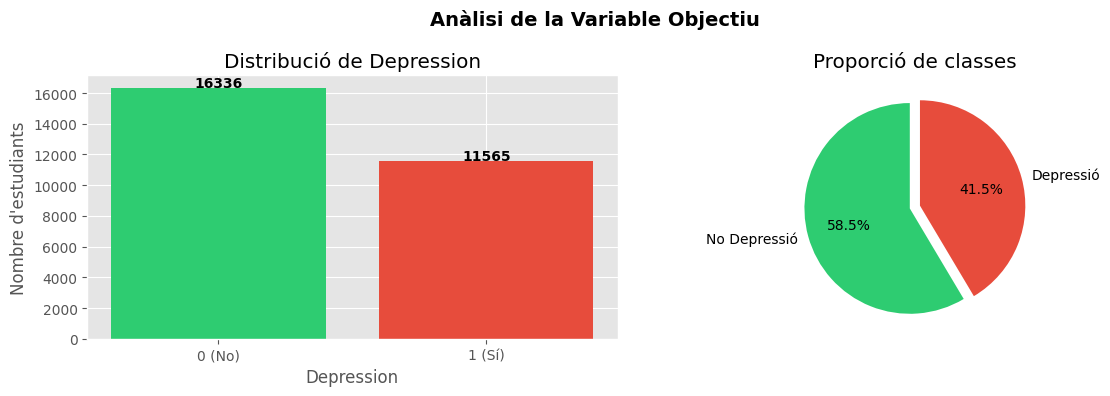


Distribució:
  No depressió (0): 11565 (41.5%)
  Depressió (1):    16336 (58.5%)

Ratio: 1:0.71


In [7]:
# Distribució de la variable objectiu
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot
counts = df['Depression'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(counts.index.astype(str), counts.values, color=colors)
axes[0].set_xlabel('Depression')
axes[0].set_ylabel('Nombre d\'estudiants')
axes[0].set_title('Distribució de Depression')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0 (No)', '1 (Sí)'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Depressió', 'Depressió'], 
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0.05, 0.05))
axes[1].set_title('Proporció de classes')

plt.suptitle('Anàlisi de la Variable Objectiu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nDistribució:")
print(f"  No depressió (0): {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"  Depressió (1):    {counts[1]} ({counts[1]/len(df)*100:.1f}%)")
print(f"\nRatio: 1:{counts[0]/counts[1]:.2f}" if counts[1] > 0 else "")

## 3. Distribució de variables numèriques

Histogrames de les variables numèriques, separades per si l'estudiant té depressió o no.

Variables numèriques (7): ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours']


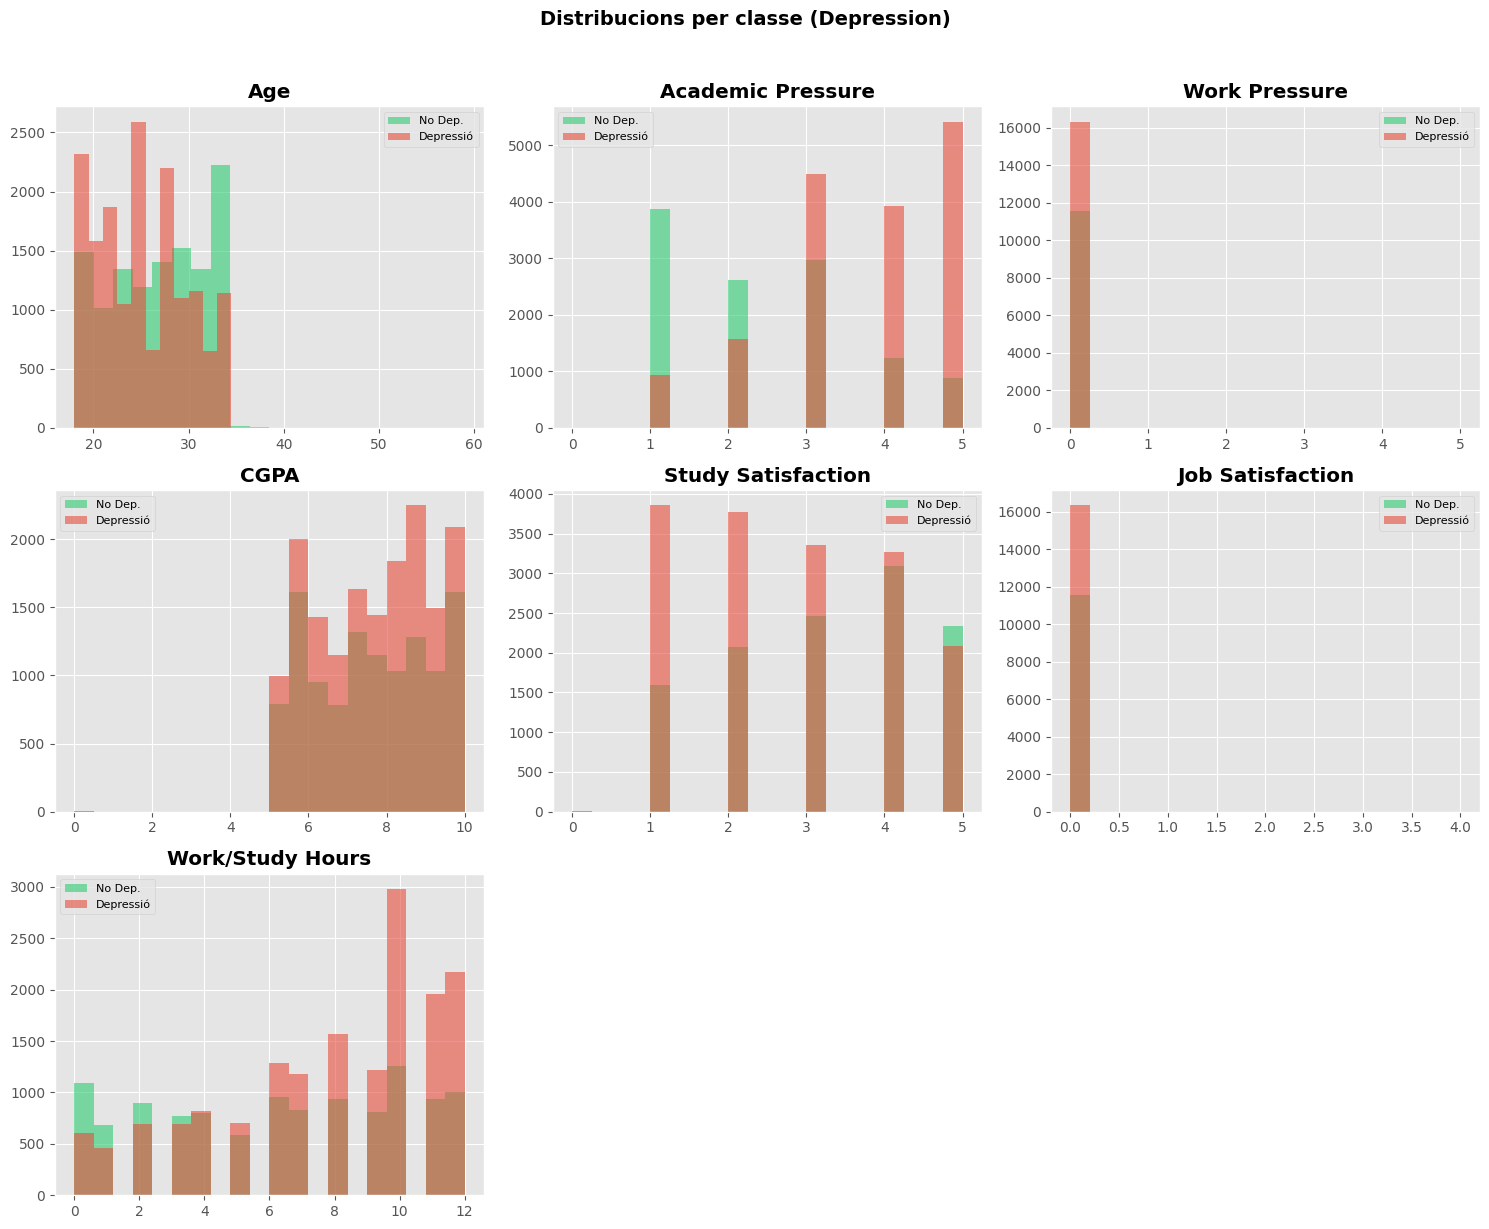

In [8]:
# Identificar columnes numèriques (excloent id i Depression)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id', 'Depression']]

print(f"Variables numèriques ({len(numeric_cols)}): {numeric_cols}")

# Histogrames separats per Depression
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df[df['Depression'] == 0][col].hist(ax=ax, alpha=0.6, label='No Dep.', color='#2ecc71', bins=20)
    df[df['Depression'] == 1][col].hist(ax=ax, alpha=0.6, label='Depressió', color='#e74c3c', bins=20)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

# Amagar eixos sobrants
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucions per classe (Depression)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

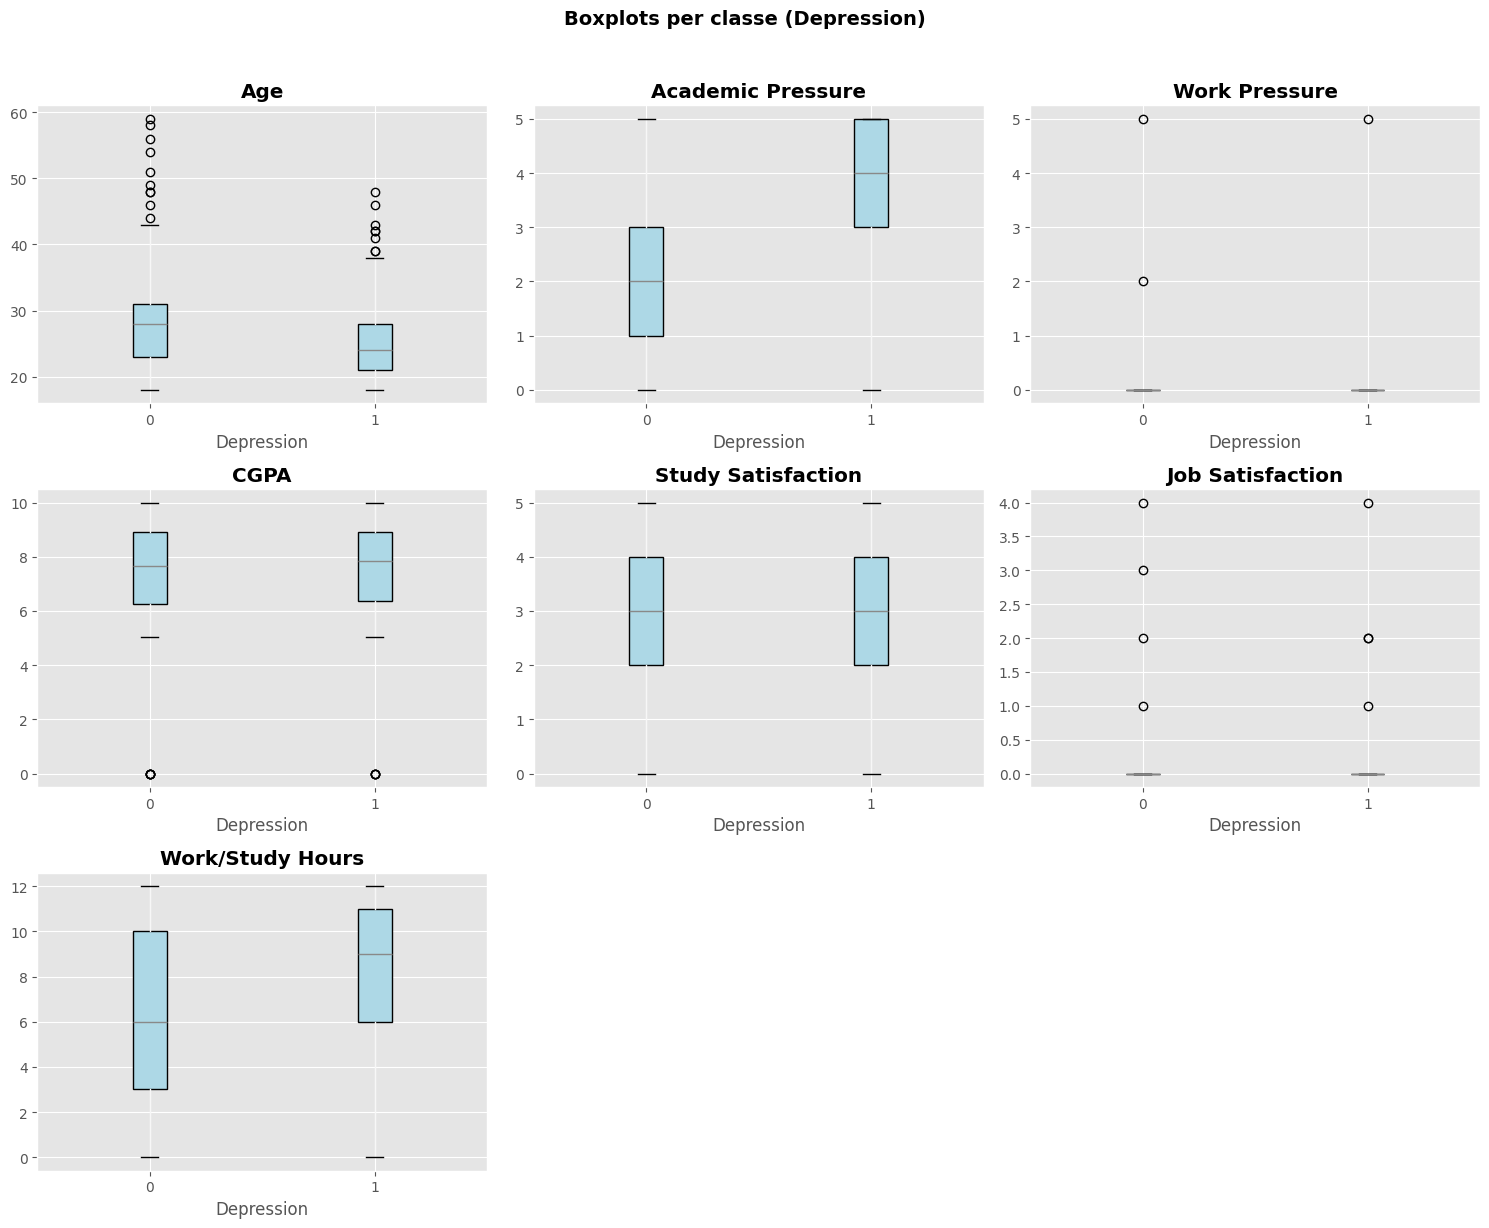

In [9]:
# Boxplots per comparar distribucions per classe
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df.boxplot(column=col, by='Depression', ax=ax, 
               patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Depression')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots per classe (Depression)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Distribució de variables categòriques

Explorar les variables categòriques i la seva relació amb la depressió.

In [10]:
# Identificar columnes categòriques
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['id']]

print(f"Variables categòriques ({len(cat_cols)}):")
for col in cat_cols:
    n_unique = df[col].nunique()
    print(f"  • {col}: {n_unique} valors únics")
    if n_unique <= 10:
        print(f"    Valors: {df[col].unique().tolist()}")

Variables categòriques (9):
  • Gender: 2 valors únics
    Valors: ['Male', 'Female']
  • City: 52 valors únics
  • Profession: 14 valors únics
  • Sleep Duration: 5 valors únics
    Valors: ["'5-6 hours'", "'Less than 5 hours'", "'7-8 hours'", "'More than 8 hours'", 'Others']
  • Dietary Habits: 4 valors únics
    Valors: ['Healthy', 'Moderate', 'Unhealthy', 'Others']
  • Degree: 28 valors únics
  • Have you ever had suicidal thoughts ?: 2 valors únics
    Valors: ['Yes', 'No']
  • Financial Stress: 6 valors únics
    Valors: ['1.0', '2.0', '5.0', '3.0', '4.0', '?']
  • Family History of Mental Illness: 2 valors únics
    Valors: ['No', 'Yes']


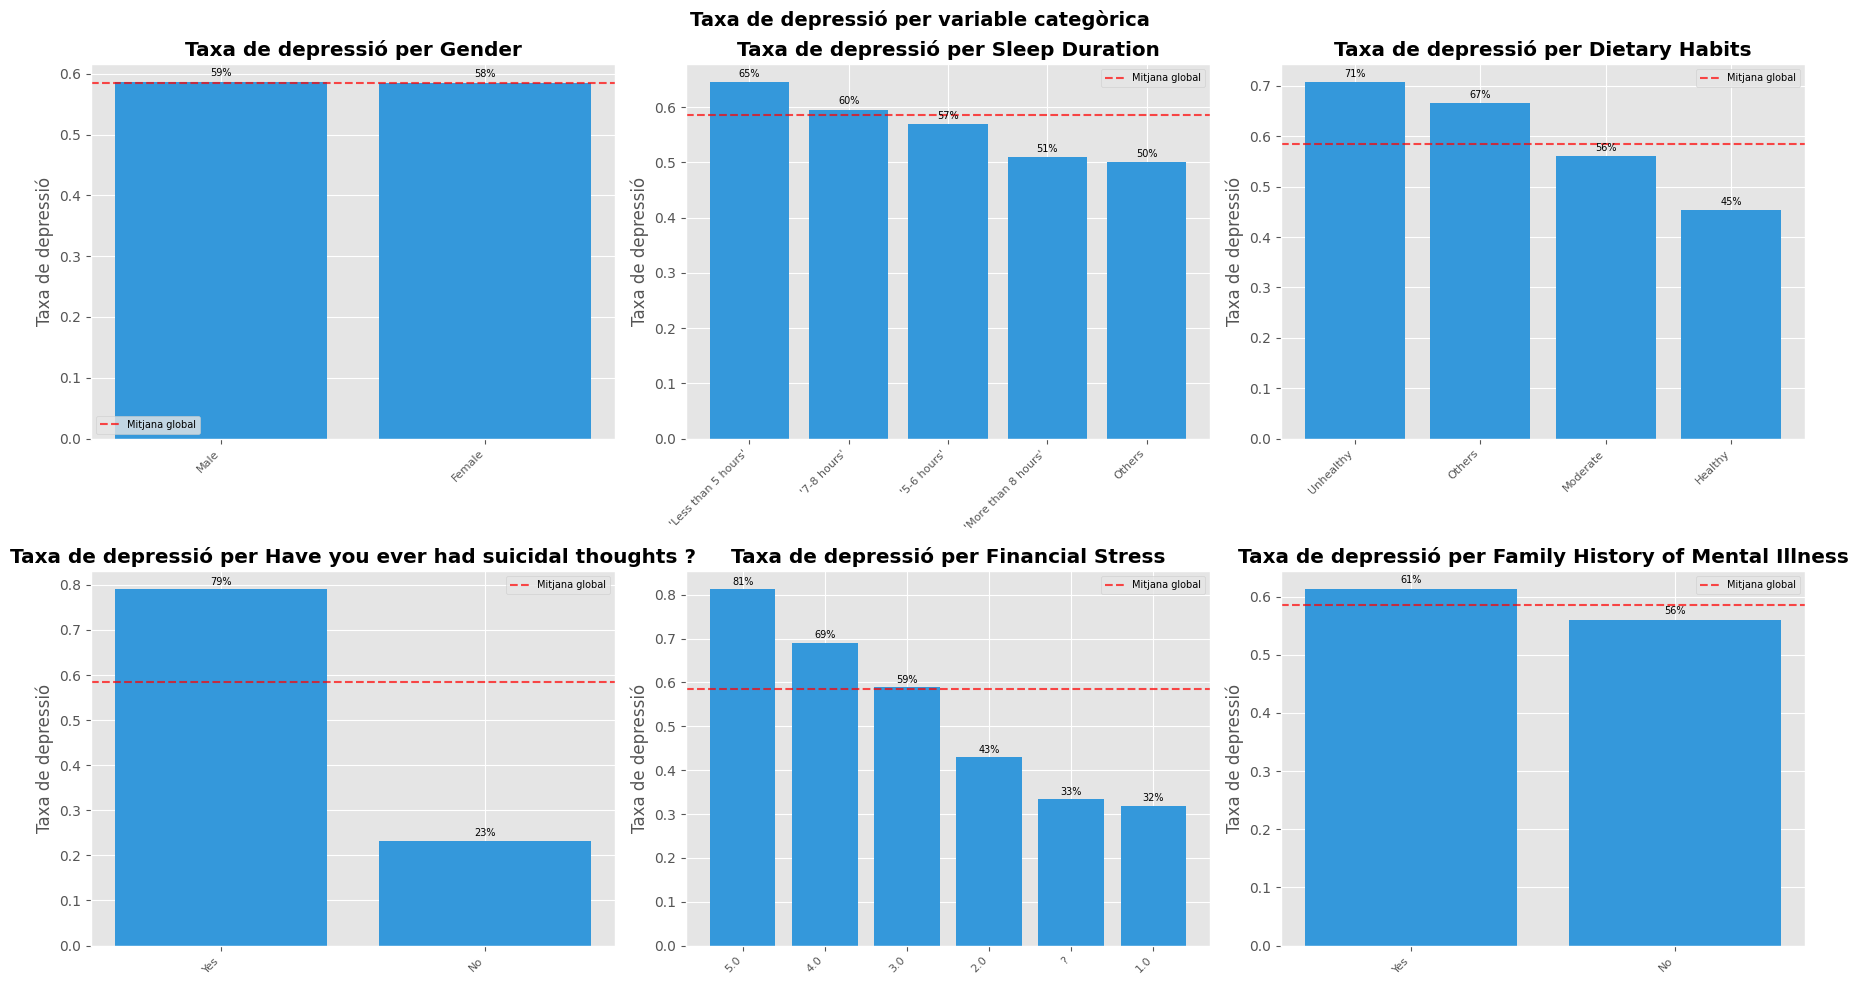

In [11]:
# Taxa de depressió per cada variable categòrica (excloent City i Degree per tenir massa categories)
cat_cols_plot = [c for c in cat_cols if df[c].nunique() <= 10]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    ax = axes[i]
    # Calcular taxa de depressió per categoria
    dep_rate = df.groupby(col)['Depression'].mean().sort_values(ascending=False)
    bars = ax.bar(range(len(dep_rate)), dep_rate.values, color='#3498db')
    ax.set_xticks(range(len(dep_rate)))
    ax.set_xticklabels(dep_rate.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Taxa de depressió')
    ax.set_title(f'Taxa de depressió per {col}', fontweight='bold')
    ax.axhline(y=df['Depression'].mean(), color='red', linestyle='--', alpha=0.7, label='Mitjana global')
    ax.legend(fontsize=7)
    
    # Afegir percentatges
    for j, v in enumerate(dep_rate.values):
        ax.text(j, v + 0.01, f'{v:.0%}', ha='center', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Taxa de depressió per variable categòrica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Matriu de correlació

Calcular i visualitzar les correlacions entre variables numèriques i la variable objectiu.

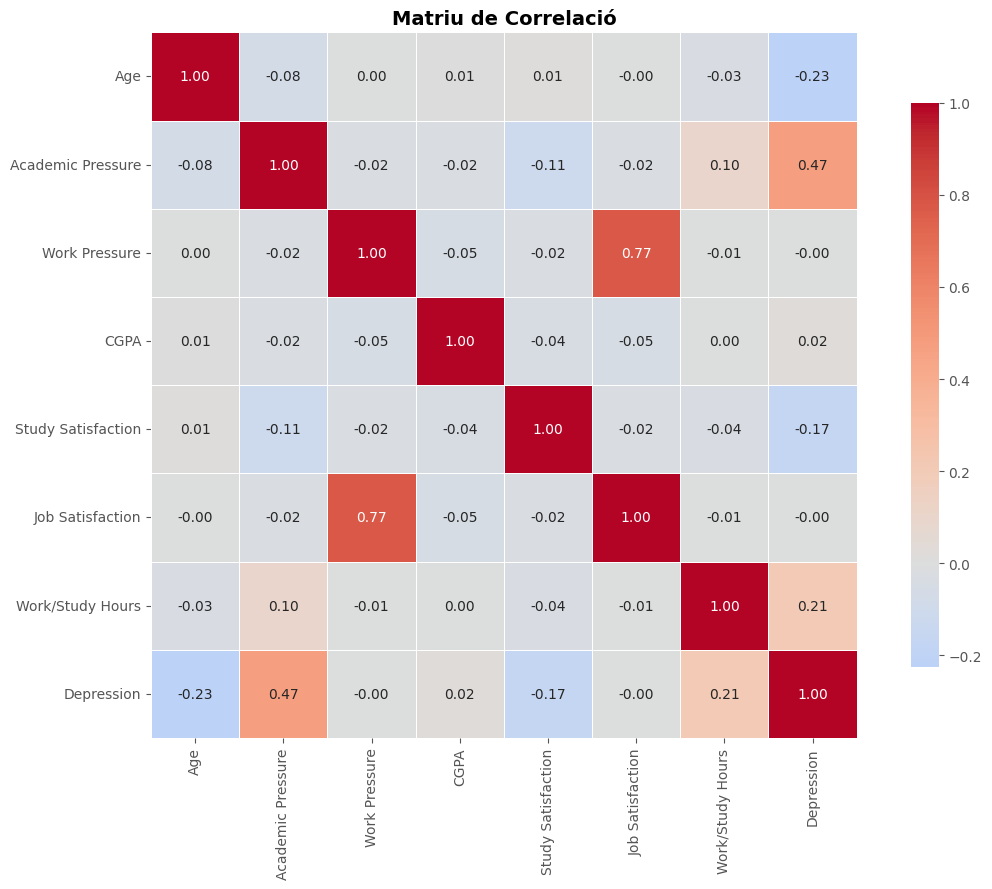


Què signifiquen aquests números?
• Valors propers a +1: relació positiva forta
• Valors propers a -1: relació negativa forta
• Valors propers a 0: relació feble o inexistent


In [12]:
# Matriu de correlació completa
corr_cols = numeric_cols + ['Depression']
correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            square=True, 
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matriu de Correlació', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nQuè signifiquen aquests números?")
print("• Valors propers a +1: relació positiva forta")
print("• Valors propers a -1: relació negativa forta")
print("• Valors propers a 0: relació feble o inexistent")

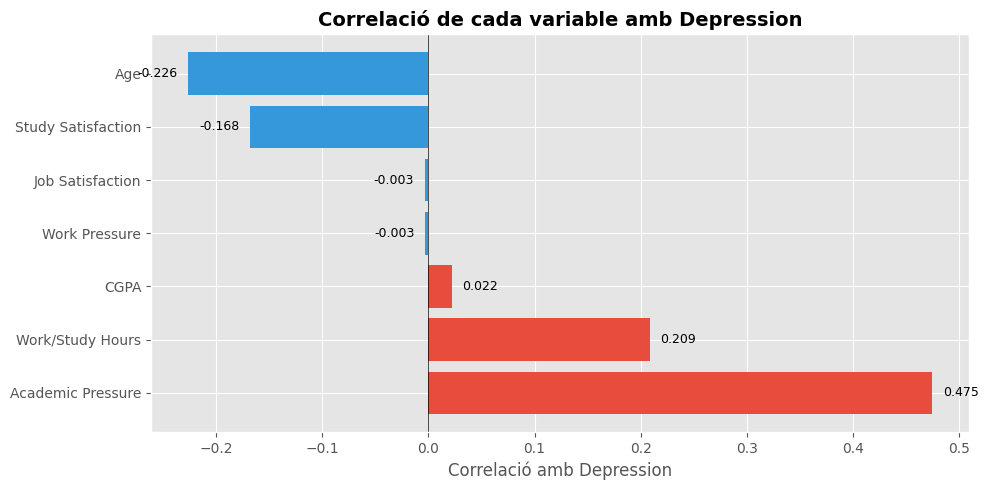


Top 3 variables més correlacionades amb Depression:
  📈 Academic Pressure: 0.475 (correlació positiva)
  📈 Work/Study Hours: 0.209 (correlació positiva)
  📈 CGPA: 0.022 (correlació positiva)

Top 3 variables menys correlacionades:
  📉 Job Satisfaction: -0.003 (correlació negativa)
  📉 Study Satisfaction: -0.168 (correlació negativa)
  📉 Age: -0.226 (correlació negativa)


In [13]:
# Correlació amb la variable objectiu, ordenada
corr_with_target = correlation_matrix['Depression'].drop('Depression').sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_target.values]
bars = plt.barh(range(len(corr_with_target)), corr_with_target.values, color=colors)
plt.yticks(range(len(corr_with_target)), corr_with_target.index)
plt.xlabel('Correlació amb Depression')
plt.title('Correlació de cada variable amb Depression', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.5)

# Afegir valors
for i, v in enumerate(corr_with_target.values):
    plt.text(v + 0.01 if v >= 0 else v - 0.01, i, f'{v:.3f}', 
             va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 3 variables més correlacionades amb Depression:")
for col, val in corr_with_target.head(3).items():
    print(f"  📈 {col}: {val:.3f} (correlació {'positiva' if val > 0 else 'negativa'})")
print("\nTop 3 variables menys correlacionades:")
for col, val in corr_with_target.tail(3).items():
    print(f"  📉 {col}: {val:.3f} (correlació {'positiva' if val > 0 else 'negativa'})")

## 6. Anàlisi de variables clau

Explorar amb més detall les variables que semblen més rellevants per la depressió.

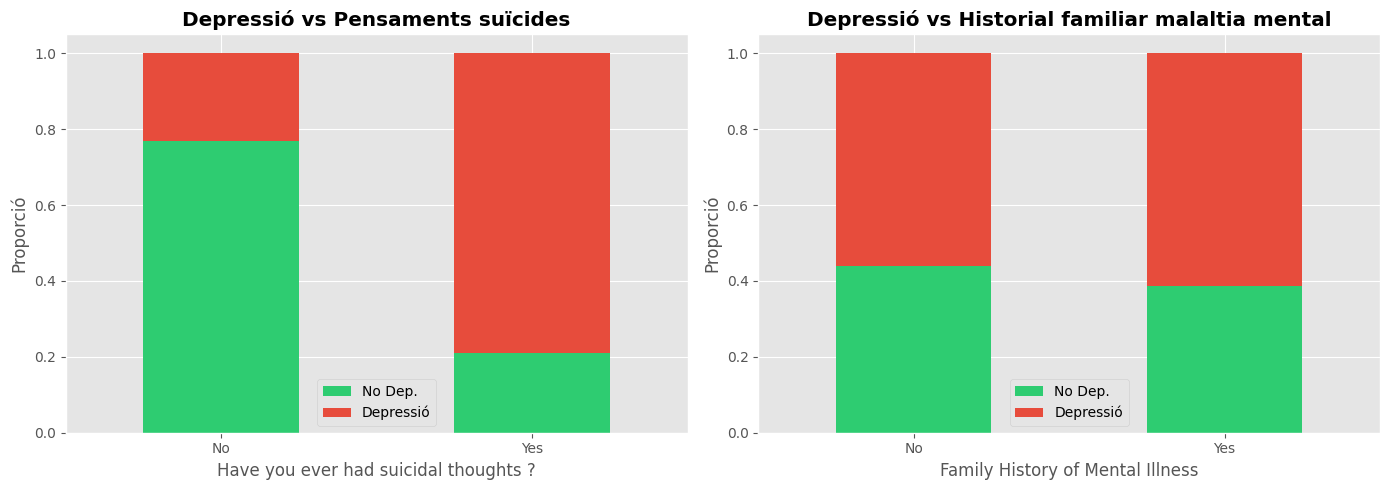

In [14]:
# Pensaments suïcides vs Depressió
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Crosstab
ct = pd.crosstab(df['Have you ever had suicidal thoughts ?'], df['Depression'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Depressió vs Pensaments suïcides', fontweight='bold')
axes[0].set_ylabel('Proporció')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['No Dep.', 'Depressió'])

# Historial familiar vs Depressió
ct2 = pd.crosstab(df['Family History of Mental Illness'], df['Depression'], normalize='index')
ct2.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Depressió vs Historial familiar malaltia mental', fontweight='bold')
axes[1].set_ylabel('Proporció')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['No Dep.', 'Depressió'])

plt.tight_layout()
plt.show()

In [16]:
# Mitjanes per grup (No Dep. vs Dep.) - només variables numèriques
key_numeric = ['Academic Pressure', 'CGPA', 'Study Satisfaction', 
               'Work/Study Hours', 'Age']

print("Mitjanes per grup (No Dep. vs Dep.):")
print("=" * 55)
for col in key_numeric:
    mean_0 = df[df['Depression'] == 0][col].mean()
    mean_1 = df[df['Depression'] == 1][col].mean()
    diff = mean_1 - mean_0
    arrow = "↑" if diff > 0 else "↓"
    print(f"  {col:25s} | No: {mean_0:6.2f} | Sí: {mean_1:6.2f} | {arrow} {abs(diff):.2f}")

# Financial Stress (convertir a numèric, ignorant '?')
fs_numeric = pd.to_numeric(df['Financial Stress'], errors='coerce')
print(f"\n  {'Financial Stress':25s} | No: {fs_numeric[df['Depression']==0].mean():6.2f} | Sí: {fs_numeric[df['Depression']==1].mean():6.2f} | ↑ {fs_numeric[df['Depression']==1].mean() - fs_numeric[df['Depression']==0].mean():.2f}")
print(f"\n⚠️  Financial Stress conté {(df['Financial Stress'] == '?').sum()} valors '?' (tractats com NaN)")

Mitjanes per grup (No Dep. vs Dep.):
  Academic Pressure         | No:   2.36 | Sí:   3.69 | ↑ 1.33
  CGPA                      | No:   7.62 | Sí:   7.68 | ↑ 0.07
  Study Satisfaction        | No:   3.22 | Sí:   2.75 | ↓ 0.46
  Work/Study Hours          | No:   6.24 | Sí:   7.81 | ↑ 1.57
  Age                       | No:  27.14 | Sí:  24.89 | ↓ 2.25

  Financial Stress          | No:   2.52 | Sí:   3.58 | ↑ 1.06

⚠️  Financial Stress conté 3 valors '?' (tractats com NaN)


## 7. Hàbits de vida i depressió

Analitzar com el son, la dieta i les hores d'estudi/treball es relacionen amb la depressió.

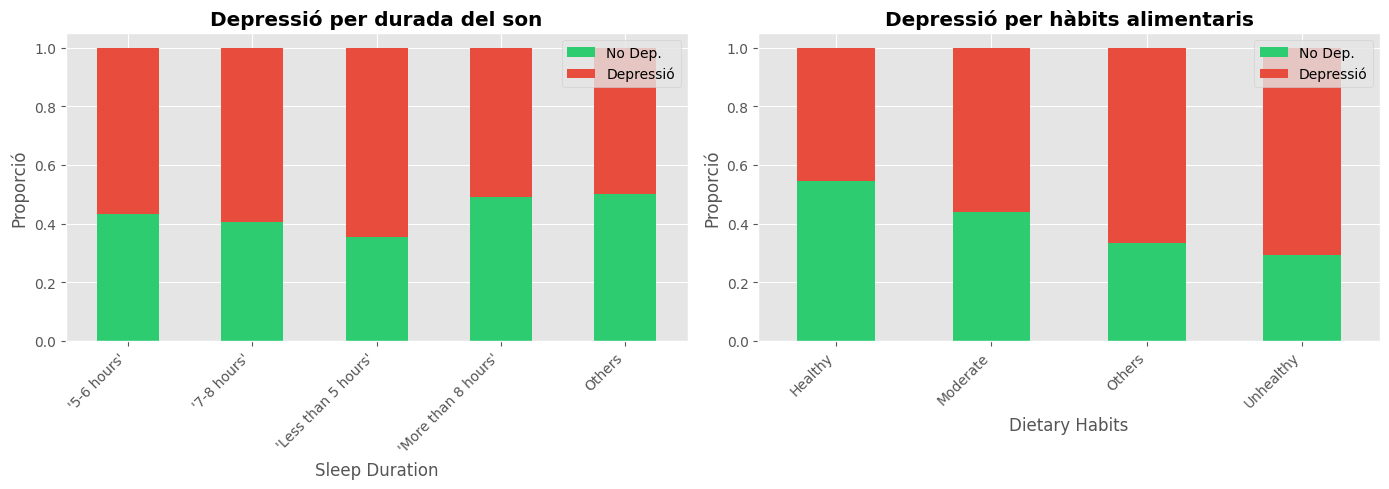

In [17]:
# Son i Dieta vs Depressió
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sleep Duration
sleep_dep = pd.crosstab(df['Sleep Duration'], df['Depression'], normalize='index')
sleep_dep.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Depressió per durada del son', fontweight='bold')
axes[0].set_ylabel('Proporció')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend(['No Dep.', 'Depressió'])

# Dietary Habits
diet_dep = pd.crosstab(df['Dietary Habits'], df['Depression'], normalize='index')
diet_dep.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Depressió per hàbits alimentaris', fontweight='bold')
axes[1].set_ylabel('Proporció')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(['No Dep.', 'Depressió'])

plt.tight_layout()
plt.show()

## 8. Resum i conclusions

Síntesi dels descobriments principals de l'anàlisi exploratori.

In [ ]:
# Resum estadístic final
print("=" * 60)
print("📊 RESUM DE L'ANÀLISI EXPLORATORI")
print("=" * 60)

print(f"\n📌 DATASET:")
print(f"   • {df.shape[0]} estudiants, {df.shape[1]} variables")
print(f"   • Variable objectiu: Depression (binària)")

dep_counts = df['Depression'].value_counts()
print(f"\n📌 BALANÇ DE CLASSES:")
print(f"   • No depressió: {dep_counts[0]} ({dep_counts[0]/len(df)*100:.1f}%)")
print(f"   • Depressió:    {dep_counts[1]} ({dep_counts[1]/len(df)*100:.1f}%)")

print(f"\n📌 QUALITAT DE DADES:")
print(f"   • Valors nuls: {df.isnull().sum().sum()}")
print(f"   • Duplicats: {df.duplicated().sum()}")

# Top correlacions
corr_target = df[corr_cols].corr()['Depression'].drop('Depression').abs().sort_values(ascending=False)
print(f"\n📌 TOP CORRELACIONS (valor absolut) AMB DEPRESSION:")
for col, val in corr_target.head(5).items():
    direction = "+" if df[corr_cols].corr()['Depression'][col] > 0 else "-"
    print(f"   • {col}: {direction}{val:.3f}")

print(f"\n📌 CONCLUSIONS PRINCIPALS:")
print(f"   1. La pressió acadèmica i l'estrès financer són factors clau")
print(f"   2. Pensaments suïcides tenen una relació molt forta amb depressió")
print(f"   3. La satisfacció amb els estudis mostra una relació inversa (protectora)")
print(f"   4. El CGPA i les hores d'estudi/treball influeixen en la depressió")
print(f"   5. Hàbits de son i dieta saludables s'associen amb menys depressió")
print(f"   6. L'historial familiar de malaltia mental és un factor de risc")

📊 RESUM DE L'ANÀLISI EXPLORATORI

📌 DATASET:
   • 27901 estudiants, 18 variables
   • Variable objectiu: Depression (binària)

📌 BALANÇ DE CLASSES:
   • No depressió: 11565 (41.5%)
   • Depressió:    16336 (58.5%)

📌 QUALITAT DE DADES:
   • Valors nuls: 0
   • Duplicats: 0

📌 TOP CORRELACIONS (valor absolut) AMB DEPRESSION:
   • Academic Pressure: +0.475
   • Age: -0.226
   • Work/Study Hours: +0.209
   • Study Satisfaction: -0.168
   • CGPA: +0.022

📌 CONCLUSIONS PRINCIPALS:
   1. La pressió acadèmica i l'estrès financer són factors clau
   2. Pensaments suïcides tenen una relació molt forta amb depressió
   3. La satisfacció amb els estudis mostra una relació inversa (protectora)
   4. El CGPA i les hores d'estudi/treball influeixen en la depressió
   5. Hàbits de son i dieta saludables s'associen amb menys depressió
   6. L'historial familiar de malaltia mental és un factor de risc

⚠️  Recordeu: Correlació ≠ Causació!
   Aquestes són associacions estadístiques, no relacions causals